# Tokenizer v2 — Reconstruction & Visualizations (local DESI data)

This notebook evaluates the **frozen spectrum tokenizer v2** on the local DESI
spectra. It is tokenizer-only: every spectrum is run through the
**encode → decode round trip** (no transformer involved).

What v2 is: a convolutional encoder + lookup-free quantizer, wavelength-aware
(resamples each spectrum onto a fixed 8704-pixel grid), trained with an
inverse-variance-weighted (Huber) Gaussian likelihood. Input and output are
**two channels** — flux and istd (= sqrt(ivar), the per-pixel inverse noise).

Metrics reported (these are the tokenizer's reconstruction quality — the analog
of AION-1's token reconstruction R² = 0.994):
- **χ² / pixel** — inverse-variance-weighted mean squared residual. ~1.0 means the
  reconstruction sits at the measurement noise (the right target).
- **Pooled high-SNR R²** — fraction of variance explained, pooled over pixels with
  per-pixel signal-to-noise > 3 (low-SNR pixels are noise-dominated, so a
  per-spectrum R² there is misleadingly low even when χ² is fine).
- **Codebook utilization** — how many of the 1024 codes the tokenizer actually uses.


## Imports & configuration

In [1]:
import sys
from pathlib import Path

REPO = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(REPO))

import numpy as np
import torch
import matplotlib.pyplot as plt

from src.tokenizers.spectrum import (
    SpectrumTokenizer, N_TOKENS, LATENT_GRID_SIZE, GRID_WAVE_MIN, GRID_WAVE_STEP,
)
from src.utils.data import DESISpectrumDataset

DATA_DIR       = REPO / 'data/desi_raw'
TOKENIZER_CKPT = REPO / 'checkpoints/release/spectrum_tokenizer_v2/best.pt'
N_SAMPLES      = 8      # spectra shown in the per-spectrum reconstruction panels
SEED           = 42

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print('tokenizer ckpt:', TOKENIZER_CKPT, '(exists:', TOKENIZER_CKPT.is_file(), ')')


device: cpu
tokenizer ckpt: /Users/jonathansamuel/projects/cs-686-dl/FoundationModel/checkpoints/release/spectrum_tokenizer_v2/best.pt (exists: True )


## Load tokenizer v2

In [2]:
spec_tok = SpectrumTokenizer().to(device).eval()
for p in spec_tok.parameters():
    p.requires_grad_(False)
_ck = torch.load(TOKENIZER_CKPT, map_location=device, weights_only=False)
_sd = _ck.get('model', _ck) if isinstance(_ck, dict) else _ck
missing, unexpected = spec_tok.load_state_dict(_sd, strict=True)
n_params = sum(p.numel() for p in spec_tok.parameters())

# The fixed latent wavelength grid the tokenizer reconstructs onto.
grid_wave = GRID_WAVE_MIN + GRID_WAVE_STEP * np.arange(LATENT_GRID_SIZE)

print(f'loaded spectrum_tokenizer_v2  step={_ck.get("step")}  '
      f'val_loss={_ck.get("val_loss")}')
print(f'  params={n_params/1e6:.1f}M   tokens/spectrum={N_TOKENS}   '
      f'latent grid={LATENT_GRID_SIZE}px  [{grid_wave[0]:.0f}–{grid_wave[-1]:.0f} Å]')


loaded spectrum_tokenizer_v2  step=80000  val_loss=0.47704170882701874
  params=24.3M   tokens/spectrum=272   latent grid=8704px  [3500–10462 Å]


## Load local DESI spectra

Reuses `DESISpectrumDataset` to read every good spectrum from the coadd files in
`DATA_DIR` (the same local data the prediction notebook uses).

In [3]:
coadd_files = sorted(DATA_DIR.glob('coadd-*.fits'))
assert coadd_files, f'No coadd-*.fits in {DATA_DIR}'
spectra = []
for f in coadd_files:
    rr = f.parent / f.name.replace('coadd-', 'redrock-')
    if not rr.exists():
        print('skip', f.name, '(no redrock)'); continue
    ds = DESISpectrumDataset(coadd_path=f, redrock_path=rr,
                             require_good_zwarn=True, require_nonzero_flux=True)
    for i in range(len(ds)):
        spectra.append(ds[i])
print(f'loaded {len(spectra)} good spectra from {len(coadd_files)} coadd files')


  Filtered out 18 bad spectra:
    18 bad fiber status
Loaded 25 good spectra from coadd-sv3-bright-10016.fits
  Wavelength range: [3600.0, 9824.0] Å
  Pixels per spectrum: 7781
  Filtered out 1 bad spectra:
    1 bad ZWARN
Loaded 4 good spectra from coadd-sv3-bright-10145.fits
  Wavelength range: [3600.0, 9824.0] Å
  Pixels per spectrum: 7781
loaded 29 good spectra from 2 coadd files


## Helpers — round-trip reconstruction + line markers

`reconstruct(specs)` stacks a list of spectra, resamples them onto the latent
grid (`x_grid`), encodes to tokens and decodes back (`recon`) — both two-channel
(flux, istd) in physical units, so they are directly comparable.

In [4]:
@torch.no_grad()
def reconstruct(specs):
    """Round-trip a list of spectrum dicts through the frozen tokenizer.
    Returns (x_grid, recon, indices) as CPU tensors:
      x_grid (B,2,G) resampled input, recon (B,2,G), indices (B,N_TOKENS)."""
    flux = torch.stack([s['flux'] for s in specs]).float()
    ivar = torch.stack([s['ivar'] for s in specs]).float()
    wave = torch.stack([s['wavelength'] for s in specs]).float()
    istd = torch.sqrt(ivar.clamp(min=1e-10))
    x = torch.stack([flux, istd], dim=1).to(device)   # (B,2,L)
    w = wave.to(device)
    x_grid = spec_tok._to_grid(x, w)                  # (B,2,G) resampled input
    idx, denorm = spec_tok.encode(x, wavelength=w)    # (B,N_TOKENS)
    recon = spec_tok.decode(idx, denorm)              # (B,2,G)
    return x_grid.cpu(), recon.cpu(), idx.cpu()

EMISSION_LINES = {'[OII]':3727,'Hβ':4861,'[OIII]5007':5007,'Hα':6563,'[SII]':6717}
ABSORPTION_LINES = {'CaK':3934,'CaH':3968,'Mgb':5175,'NaD':5893,'CaT':8542}

def mark_lines(ax, z, wlo, whi, fontsize=6.5):
    trans = ax.get_xaxis_transform()
    for lab, lam in EMISSION_LINES.items():
        obs = lam*(1+z)
        if wlo <= obs <= whi:
            ax.axvline(obs, color='green', lw=0.6, ls='--', alpha=0.4)
            ax.text(obs,0.97,lab,transform=trans,fontsize=fontsize,color='green',
                    rotation=90,va='top',ha='right',alpha=0.8)
    for lab, lam in ABSORPTION_LINES.items():
        obs = lam*(1+z)
        if wlo <= obs <= whi:
            ax.axvline(obs, color='darkorange', lw=0.6, ls=':', alpha=0.4)
            ax.text(obs,0.97,lab,transform=trans,fontsize=fontsize,color='darkorange',
                    rotation=90,va='top',ha='right',alpha=0.8)


## Visualization 1 — Flux reconstructions

Each spectrum gets three rows: **flux** (blue = resampled input, red = tokenizer
reconstruction), **residual** (input − reconstruction), and the **raw 1σ noise**
(`1/istd`) so you can see whether the residual sits within the measurement noise.
The reconstruction target is the input *after* resampling onto the latent grid —
this isolates the quantizer/decoder, not the resampling.

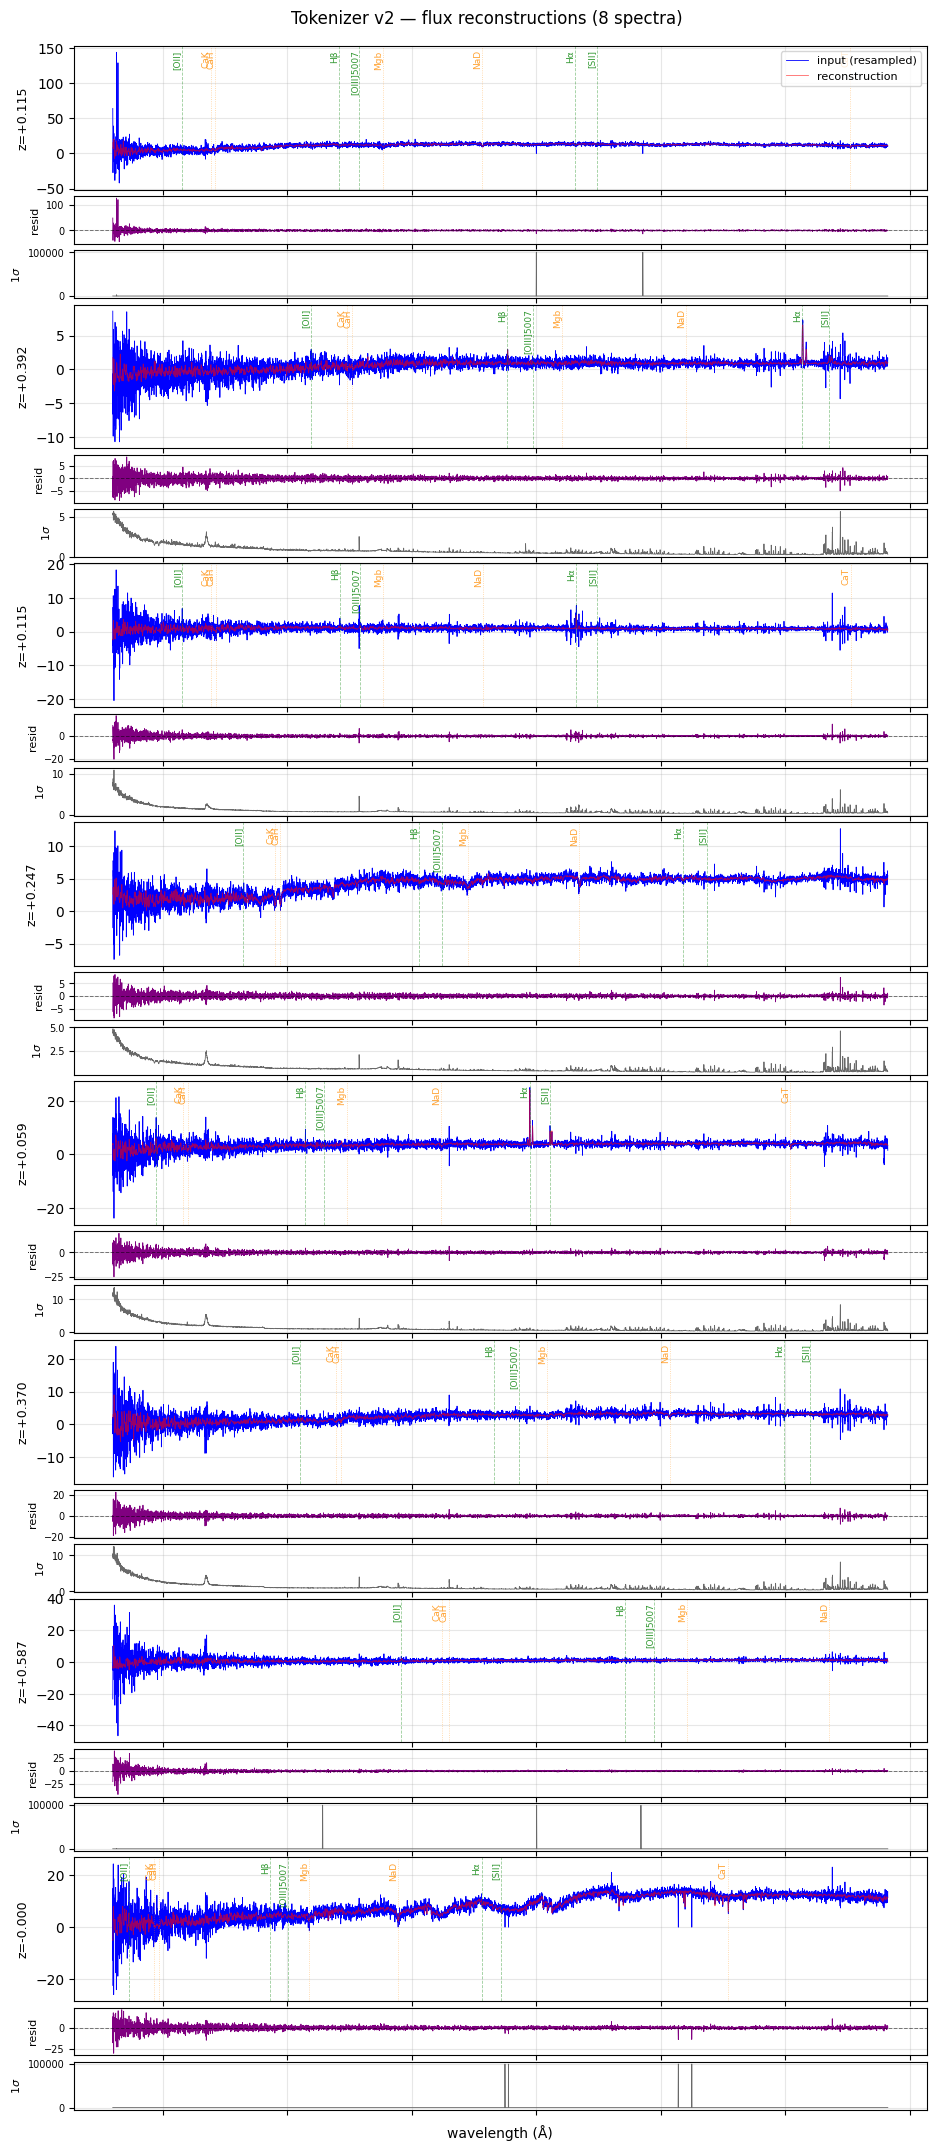

In [5]:
rng = np.random.default_rng(SEED)
sample_idx = rng.choice(len(spectra), size=min(N_SAMPLES, len(spectra)), replace=False)
sample_specs = [spectra[i] for i in sample_idx]
xg, rc, _ = reconstruct(sample_specs)

cov_lo, cov_hi = 3600.0, 9824.0   # DESI coverage; outside this istd=0
height_ratios = [h for _ in range(len(sample_specs)) for h in (3, 1, 1)]
fig, axes = plt.subplots(len(sample_specs)*3, 1, figsize=(11, 3.0*len(sample_specs)),
                         gridspec_kw={'height_ratios': height_ratios, 'hspace': 0.08},
                         sharex=True)
for i in range(len(sample_specs)):
    ax_f, ax_r, ax_n = axes[i*3], axes[i*3+1], axes[i*3+2]
    ft, fr = xg[i,0].numpy(), rc[i,0].numpy()
    it = xg[i,1].numpy()
    sig = np.where(it > 0, 1.0/np.maximum(it, 1e-9), np.nan)
    resid = np.where(it > 0, ft-fr, np.nan)
    z = float(sample_specs[i]['z'])

    ax_f.plot(grid_wave, np.where(it>0, ft, np.nan), color='blue', lw=0.6, label='input (resampled)')
    ax_f.plot(grid_wave, np.where(it>0, fr, np.nan), color='red', lw=0.6, alpha=0.6, label='reconstruction')
    mark_lines(ax_f, z, cov_lo, cov_hi)
    ax_f.set_ylabel(f'z={z:+.3f}', fontsize=9); ax_f.grid(alpha=0.3); ax_f.set_xticklabels([])
    if i == 0: ax_f.legend(loc='upper right', fontsize=8)

    ax_r.plot(grid_wave, resid, color='purple', lw=0.6)
    ax_r.axhline(0, color='k', lw=0.7, ls='--', alpha=0.5)
    ax_r.set_ylabel('resid', fontsize=8); ax_r.grid(alpha=0.3)
    ax_r.tick_params(axis='y', labelsize=7); ax_r.set_xticklabels([])

    ax_n.plot(grid_wave, sig, color='dimgray', lw=0.6)
    ax_n.set_ylabel('1$\\sigma$', fontsize=8); ax_n.grid(alpha=0.3)
    ax_n.tick_params(axis='y', labelsize=7)
    if i < len(sample_specs)-1: ax_n.set_xticklabels([])

axes[-1].set_xlabel('wavelength (Å)')
fig.subplots_adjust(top=0.97)
fig.suptitle(f'Tokenizer v2 — flux reconstructions ({len(sample_specs)} spectra)', y=0.985)
plt.show()


## Visualization 2 — Noise-channel (istd) reconstruction

The tokenizer also reconstructs the second channel, istd = sqrt(ivar). This shows
it preserves *where* the spectrum is reliable (high istd) vs noisy (low istd).

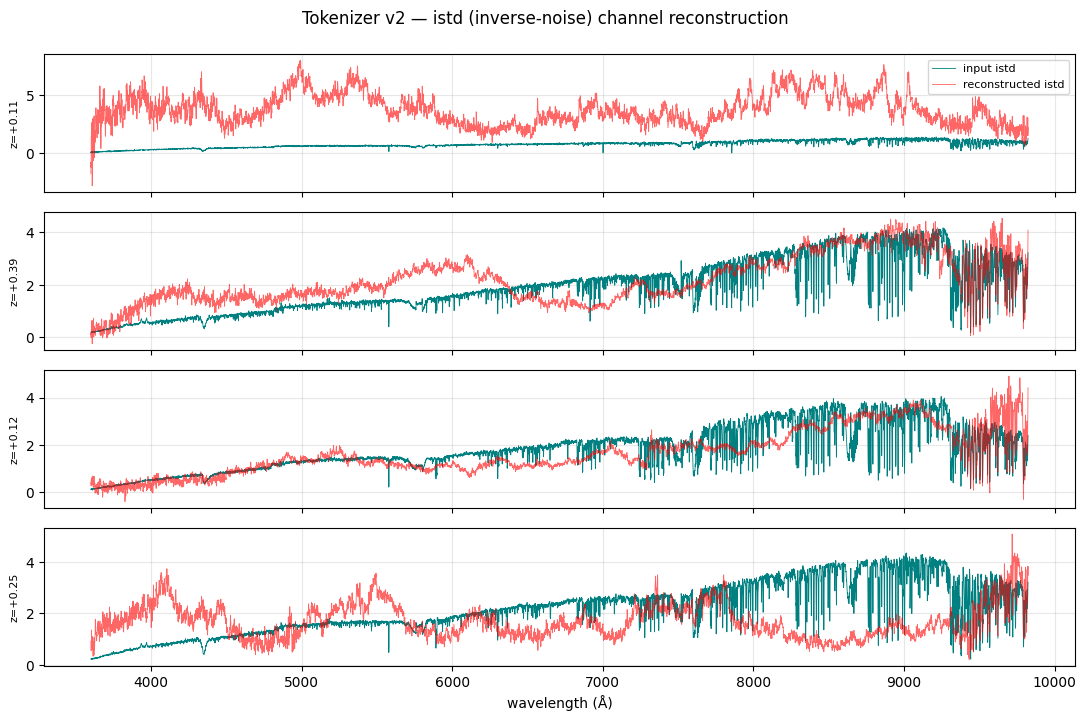

In [6]:
n2 = min(4, len(sample_specs))
fig, axes = plt.subplots(n2, 1, figsize=(11, 1.8*n2), sharex=True)
if n2 == 1: axes = [axes]
for i in range(n2):
    it, ir = xg[i,1].numpy(), rc[i,1].numpy()
    m = it > 0
    axes[i].plot(grid_wave, np.where(m, it, np.nan), color='teal', lw=0.6, label='input istd')
    axes[i].plot(grid_wave, np.where(m, ir, np.nan), color='red', lw=0.6, alpha=0.6, label='reconstructed istd')
    axes[i].set_ylabel(f'z={float(sample_specs[i]["z"]):+.2f}', fontsize=8)
    axes[i].grid(alpha=0.3)
    if i == 0: axes[i].legend(loc='upper right', fontsize=8)
axes[-1].set_xlabel('wavelength (Å)')
fig.suptitle('Tokenizer v2 — istd (inverse-noise) channel reconstruction', y=0.995)
plt.tight_layout(); plt.show()


## Visualization 3 — Reconstruction metrics over all local spectra

Per-spectrum **χ² / pixel** and ivar-weighted R², plus the **pooled high-SNR R²**
across all spectra. χ²/pixel near 1.0 means reconstruction at the noise level.

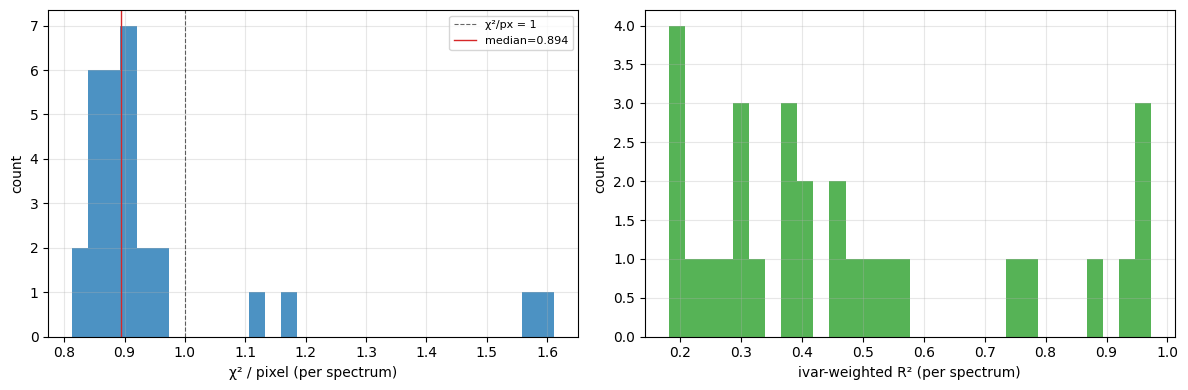

spectra evaluated      : 29
χ² / pixel  median       : 0.894   mean: 0.954
pooled R² (SNR>3)       : 0.9933
per-spectrum R² median  : 0.4115
reference: AION-1 token reconstruction R² = 0.994; our v2 run pooled-SNR R² ≈ 0.876


In [7]:
# Round-trip every spectrum (in batches) and accumulate pixel pools.
def batched(seq, n):
    for i in range(0, len(seq), n):
        yield seq[i:i+n]

per_chi2, per_r2 = [], []
F_hi, R_hi, W_hi = [], [], []   # high-SNR pixel pool for the pooled R2
all_indices = []
for chunk in batched(spectra, 16):
    xg_c, rc_c, idx_c = reconstruct(chunk)
    ft, fr, it = xg_c[:,0].numpy(), rc_c[:,0].numpy(), xg_c[:,1].numpy()
    iv = it**2
    all_indices.append(idx_c.numpy().ravel())
    for i in range(len(chunk)):
        v = iv[i] > 0
        if v.sum() < 10: continue
        chi2 = float((iv[i,v]*(ft[i,v]-fr[i,v])**2).mean())
        wm = np.average(ft[i,v], weights=iv[i,v])
        num = (iv[i,v]*(ft[i,v]-fr[i,v])**2).sum()
        den = (iv[i,v]*(ft[i,v]-wm)**2).sum()
        per_chi2.append(chi2)
        per_r2.append(1 - num/den if den > 0 else np.nan)
        snr = ft[i]*it[i]                       # per-pixel signal-to-noise
        hi = v & (np.abs(snr) > 3)
        F_hi.append(ft[i,hi]); R_hi.append(fr[i,hi]); W_hi.append(iv[i,hi])

per_chi2 = np.array(per_chi2); per_r2 = np.array(per_r2)
F_hi = np.concatenate(F_hi); R_hi = np.concatenate(R_hi); W_hi = np.concatenate(W_hi)
wm = np.average(F_hi, weights=W_hi)
pooled_r2 = 1 - (W_hi*(F_hi-R_hi)**2).sum()/(W_hi*(F_hi-wm)**2).sum()

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
a1.hist(per_chi2, bins=30, color='C0', alpha=0.8)
a1.axvline(1.0, color='k', ls='--', lw=0.8, alpha=0.6, label='χ²/px = 1')
a1.axvline(np.median(per_chi2), color='C3', ls='-', lw=1.0, label=f'median={np.median(per_chi2):.3f}')
a1.set_xlabel('χ² / pixel (per spectrum)'); a1.set_ylabel('count'); a1.legend(fontsize=8); a1.grid(alpha=0.3)
a2.hist(per_r2[np.isfinite(per_r2)], bins=30, color='C2', alpha=0.8)
a2.set_xlabel('ivar-weighted R² (per spectrum)'); a2.set_ylabel('count'); a2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f'spectra evaluated      : {len(per_chi2)}')
print(f'χ² / pixel  median       : {np.median(per_chi2):.3f}   mean: {per_chi2.mean():.3f}')
print(f'pooled R² (SNR>3)       : {pooled_r2:.4f}')
print(f'per-spectrum R² median  : {np.nanmedian(per_r2):.4f}')
print('reference: AION-1 token reconstruction R² = 0.994; our v2 run pooled-SNR R² ≈ 0.876')


## Visualization 4 — Codebook utilization

How many of the 1024 quantizer codes the tokenizer actually uses across all local
spectra, and how evenly. A collapsed codebook (few codes) wastes capacity.

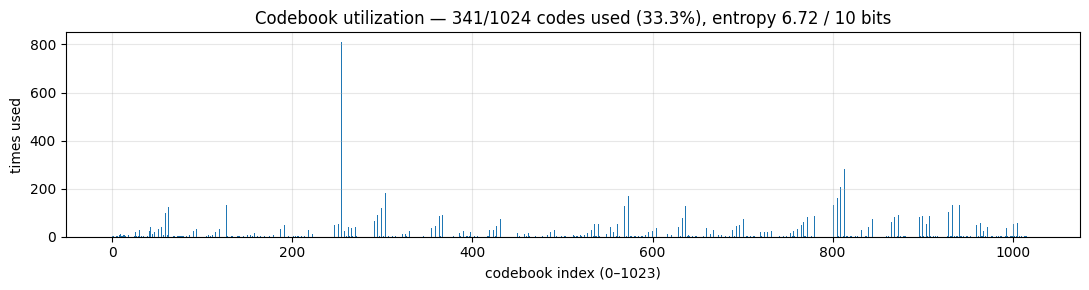

total tokens emitted : 7888  (29 spectra × 272)
codes used           : 341/1024  (33.3%)
code entropy         : 6.72 bits  (max 10)


In [8]:
codes = np.concatenate(all_indices)
counts = np.bincount(codes, minlength=1024).astype(float)
used = int((counts > 0).sum())
p = counts/counts.sum()
nz = p[p > 0]
entropy_bits = float(-(nz*np.log2(nz)).sum())

fig, ax = plt.subplots(figsize=(11, 3))
ax.bar(np.arange(1024), counts, width=1.0, color='C0')
ax.set_xlabel('codebook index (0–1023)'); ax.set_ylabel('times used')
ax.set_title(f'Codebook utilization — {used}/1024 codes used ({used/1024:.1%}), '
             f'entropy {entropy_bits:.2f} / {np.log2(1024):.0f} bits')
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

print(f'total tokens emitted : {len(codes)}  ({len(spectra)} spectra × {N_TOKENS})')
print(f'codes used           : {used}/1024  ({used/1024:.1%})')
print(f'code entropy         : {entropy_bits:.2f} bits  (max {np.log2(1024):.0f})')


## What to look for

| signal | interpretation |
|---|---|
| Reconstruction tracks the input, residual within the 1σ noise band | tokenizer reconstructs at the measurement-noise level (the goal) |
| **χ² / pixel ≈ 1** | calibrated reconstruction — not over- or under-fitting the noise |
| **Pooled high-SNR R²** high (toward AION's 0.994) | real signal (lines, breaks) is preserved where the data is informative |
| Per-spectrum R² low on bright/low-SNR objects | expected — those pixels are noise-dominated; use χ² and pooled high-SNR R² instead |
| istd channel reconstructed | tokenizer preserves where the spectrum is reliable |
| Codebook utilization high & even | quantizer not collapsed; capacity used |

This is the **tokenizer's** reconstruction quality only — the transformer is not
involved. It is the apples-to-apples comparison against AION-1's token
reconstruction R² = 0.994.
